In [1]:
%matplotlib inline

import sys
from pathlib import Path


def ensure_project_src_path() -> Path:
    """Coloca a raiz do repositório em sys.path para `import src....` funcionar.

    Funciona se o cwd for a raiz do projeto, a pasta notebooks/, ou outro
    subdiretório (sobe os pais até achar src/__init__.py).
    """
    cwd = Path.cwd().resolve()
    root = None
    for d in [cwd, *cwd.parents]:
        if (d / "src" / "__init__.py").is_file():
            root = d
            break
    if root is None:
        root = cwd.parent if cwd.name.lower() == "notebooks" else cwd
    s = str(root)
    if s not in sys.path:
        sys.path.insert(0, s)
    return root


project_root = ensure_project_src_path()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: C:\Projetos Programação\Cursor\Desafio 3 - Machine Learning
sys.path[0]: C:\Projetos Programação\Cursor\Desafio 3 - Machine Learning


In [2]:
import sys
from pathlib import Path

# Garante que os imports de src.* funcionem ao executar o notebook em pastas diferentes.
_c = Path.cwd().resolve()
_root = None
for _d in [_c, *_c.parents]:
    if (_d / "src" / "__init__.py").is_file():
        _root = _d
        break
if _root is None:
    _root = _c.parent if _c.name.lower() == "notebooks" else _c
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
project_root = _root

# Define fonte de dados e variável alvo da classificação.
csv_path = project_root / "dataset_ambiental.csv"
target = "Qualidade_Ambiental"

from src.eda import carregar_dados, validate_target_column
from src.preprocess import coerce_feature_columns_to_numeric

# Carrega os dados e valida se a coluna-alvo existe antes de continuar.
df = carregar_dados(csv_path)
validate_target_column(df, target)

# Converte features para numérico e transforma valores inválidos (ex.: "erro_sensor") em NaN.
df = coerce_feature_columns_to_numeric(df, target=target)

# Primeira inspeção rápida para entender estrutura e qualidade dos registros.
df.head()

,Temperatura,Umidade,CO2,CO,Pressao_Atm,NO2,SO2,O3,Qualidade_Ambiental
0,21.236204,46.154857,1540.997129,31.907228,979.8912041204417,85.487475,37.336205,14.692721,Moderada
1,38.521429,43.303847,613.670393,22.964623,959.4817775162059,51.979119,44.173992,101.135508,Moderada
2,31.959818,32.330774,19998.316609,48.224926,962.6359224972216,23.569233,23.695814,37.423834,Moderada
3,27.959755,62.508667,1427.577083,10.948923,968.0671128180921,74.980970,15.169758,41.233110,Moderada
4,14.680559,53.363691,1119.551886,29.392821,970.3653334364949,44.774423,16.623482,34.886981,Moderada



=== PRIMEIRAS LINHAS ===
   Temperatura    Umidade           CO2         CO        Pressao_Atm  \
0    21.236204  46.154857   1540.997129  31.907228  979.8912041204417   
1    38.521429  43.303847    613.670393  22.964623  959.4817775162059   
2    31.959818  32.330774  19998.316609  48.224926  962.6359224972216   
3    27.959755  62.508667   1427.577083  10.948923  968.0671128180921   
4    14.680559  53.363691   1119.551886  29.392821  970.3653334364949   

         NO2        SO2          O3 Qualidade_Ambiental  
0  85.487475  37.336205   14.692721            Moderada  
1  51.979119  44.173992  101.135508            Moderada  
2  23.569233  23.695814   37.423834            Moderada  
3  74.980970  15.169758   41.233110            Moderada  
4  44.774423  16.623482   34.886981            Moderada  

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------     

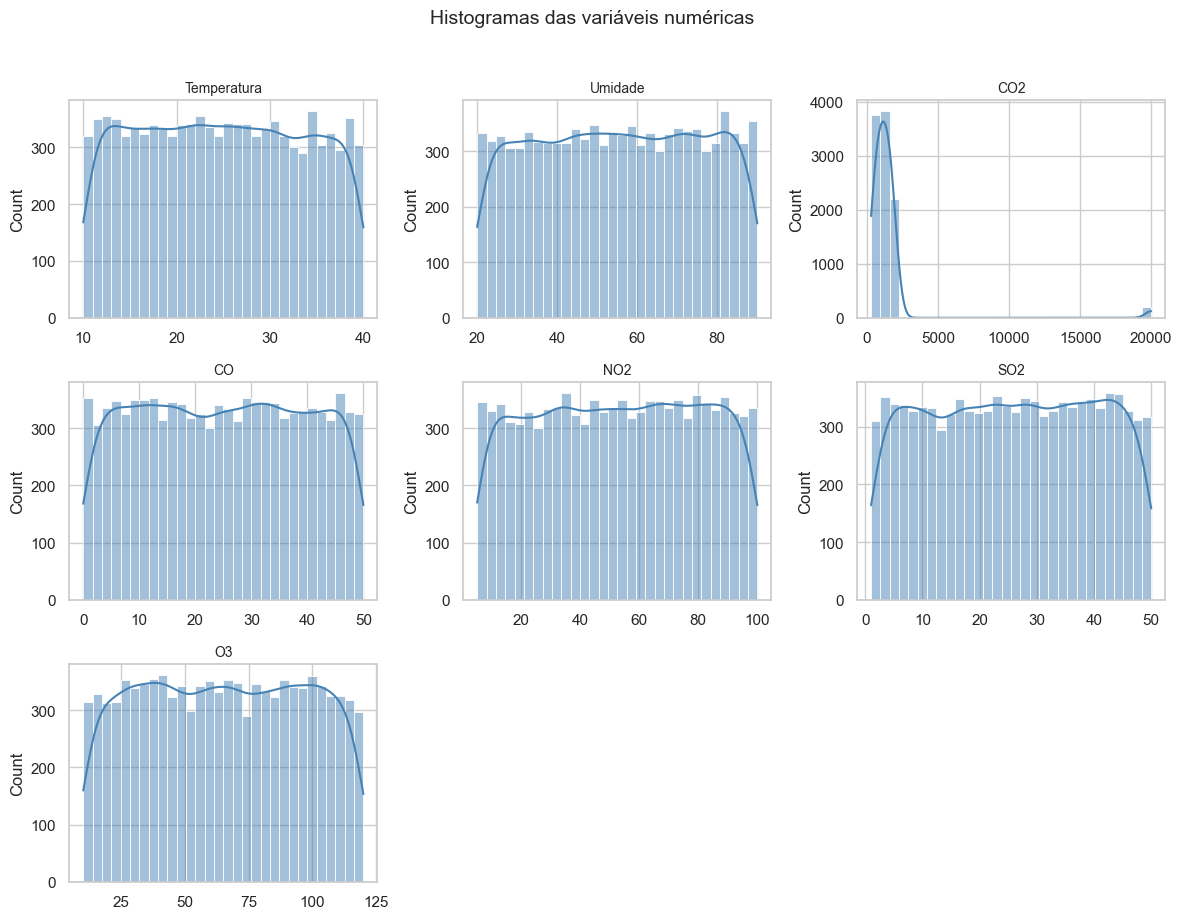

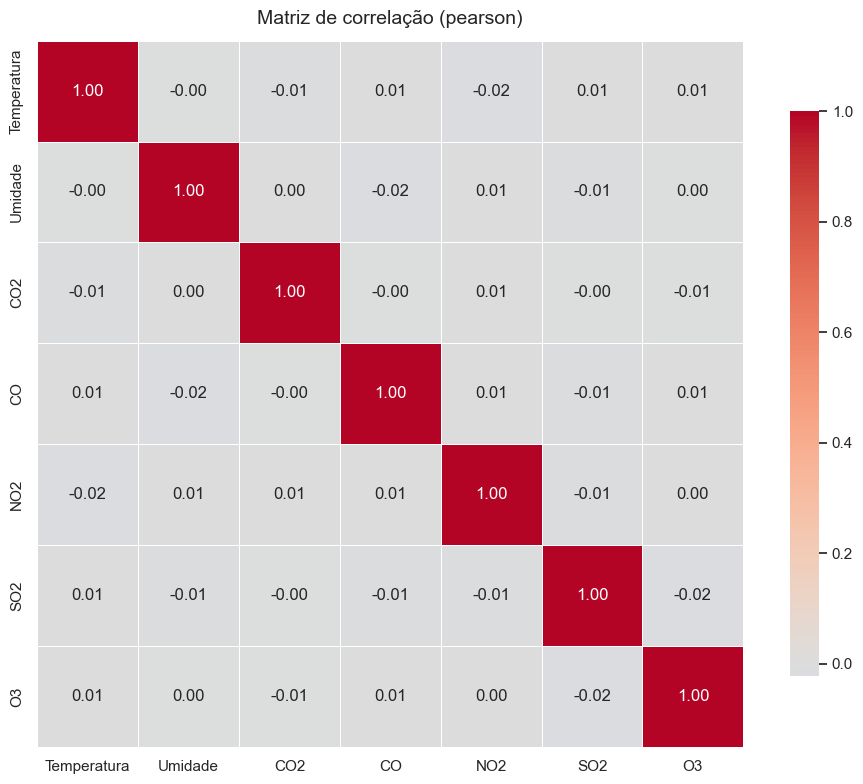

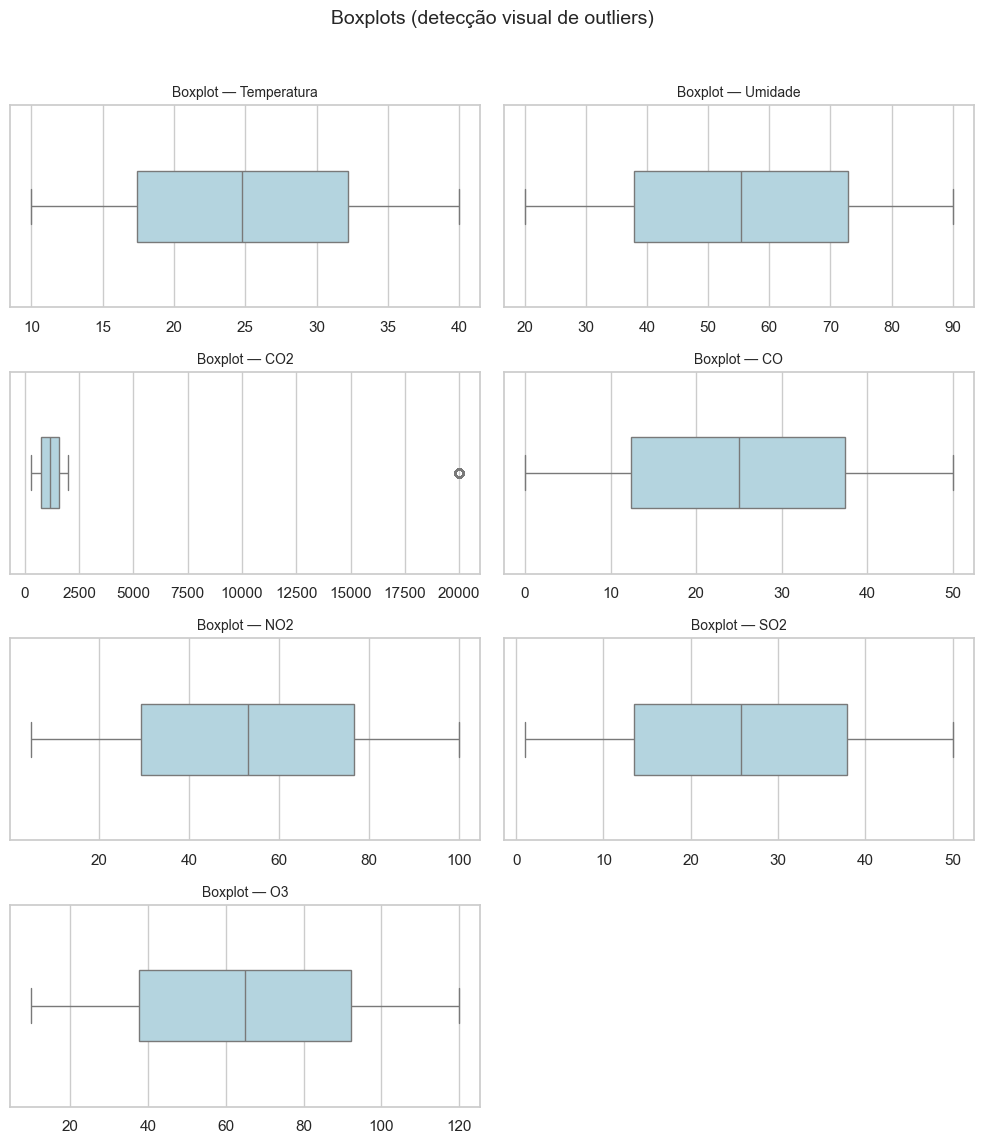

In [3]:
import sys
from pathlib import Path

# Reforça o caminho do projeto para evitar falha de import entre execuções parciais.
_c = Path.cwd().resolve()
_root = None
for _d in [_c, *_c.parents]:
    if (_d / "src" / "__init__.py").is_file():
        _root = _d
        break
if _root is None:
    _root = _c.parent if _c.name.lower() == "notebooks" else _c
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.eda import (
    print_head,
    print_info,
    print_describe,
    print_null_counts,
    plot_histograms,
    plot_correlation_matrix,
    plot_boxplots_outliers,
)

# Analise descritiva textual: tipos, estatisticas e dados faltantes.
print_head(df)
print_info(df)
print_describe(df)
print_null_counts(df)

# Analise grafica:
# - histogramas: distribuicao das variaveis
# - correlacao: relacoes lineares entre features numericas
# - boxplots: possiveis outliers por classe da variavel alvo
plot_histograms(df, target=target)
plot_correlation_matrix(df)
plot_boxplots_outliers(df, target=target)

In [4]:
df.shape[0]


10000

In [5]:
# Nulos por coluna, separados por categoria de Qualidade_Ambiental (`target` vem da célula de carga do CSV)

print("=== Linhas por categoria (Qualidade_Ambiental) ===")
linhas_por_cat = df.groupby(target, dropna=False).size().sort_index()
print(linhas_por_cat.to_string())
print()

print("=== Nulos por coluna, em cada categoria ===")
nulos_por_categoria = df.groupby(target, dropna=False)[df.columns].apply(
    lambda g: g.isnull().sum()
)
print(nulos_por_categoria.to_string())
print()

df_aux = df.assign(_any_null=df.isnull().any(axis=1))
resumo_linhas_nulos = (
    df_aux.groupby(target, dropna=False)
    .agg(
        linhas_total=("_any_null", "count"),
        com_algum_nulo=("_any_null", "sum"),
    )
)
resumo_linhas_nulos["sem_nulo"] = (
    resumo_linhas_nulos["linhas_total"] - resumo_linhas_nulos["com_algum_nulo"]
)
resumo_linhas_nulos = resumo_linhas_nulos[
    ["linhas_total", "com_algum_nulo", "sem_nulo"]
]
print("=== Por categoria: total, com algum nulo, sem nulo (todas as colunas preenchidas) ===")
print(resumo_linhas_nulos.to_string())

nulos_por_categoria

=== Linhas por categoria (Qualidade_Ambiental) ===
Qualidade_Ambiental
Boa           1453
Excelente       11
Moderada      5912
Muito Ruim      55
Ruim          2569

=== Nulos por coluna, em cada categoria ===
                     Temperatura  Umidade  CO2  CO  Pressao_Atm  NO2  SO2  O3  Qualidade_Ambiental
Qualidade_Ambiental                                                                               
Boa                           23       26    0   0            0    0    0   0                    0
Excelente                      0        0    0   0            0    0    0   0                    0
Moderada                      55      132    0   0            0    0    0   0                    0
Muito Ruim                     1        0    0   0            0    0    0   0                    0
Ruim                          21       42    0   0            0    0    0   0                    0

=== Por categoria: total, com algum nulo, sem nulo (todas as colunas preenchidas) ===
         

,Temperatura,Umidade,CO2,CO,Pressao_Atm,NO2,SO2,O3,Qualidade_Ambiental
Qualidade_Ambiental,,,,,,,,,
Boa,23,26,0,0,0,0,0,0,0
Excelente,0,0,0,0,0,0,0,0,0
Moderada,55,132,0,0,0,0,0,0,0
Muito Ruim,1,0,0,0,0,0,0,0,0
Ruim,21,42,0,0,0,0,0,0,0


In [6]:
import sys
from pathlib import Path

# Mantem compatibilidade de import quando a execucao nao comeca na primeira celula.
_c = Path.cwd().resolve()
_root = None
for _d in [_c, *_c.parents]:
    if (_d / "src" / "__init__.py").is_file():
        _root = _d
        break
if _root is None:
    _root = _c.parent if _c.name.lower() == "notebooks" else _c
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.preprocess import preprocessar_dados

# Separa features (X) e alvo (y), aplicando limpeza definida no modulo de preprocessamento.
X, y = preprocessar_dados(df, target=target, drop_na=True)

# Confere dimensoes para validar se nenhuma etapa removeu dados em excesso.
X.shape, y.shape


Linhas após remoção de nulos: 9604


((9604, 8), (9604,))

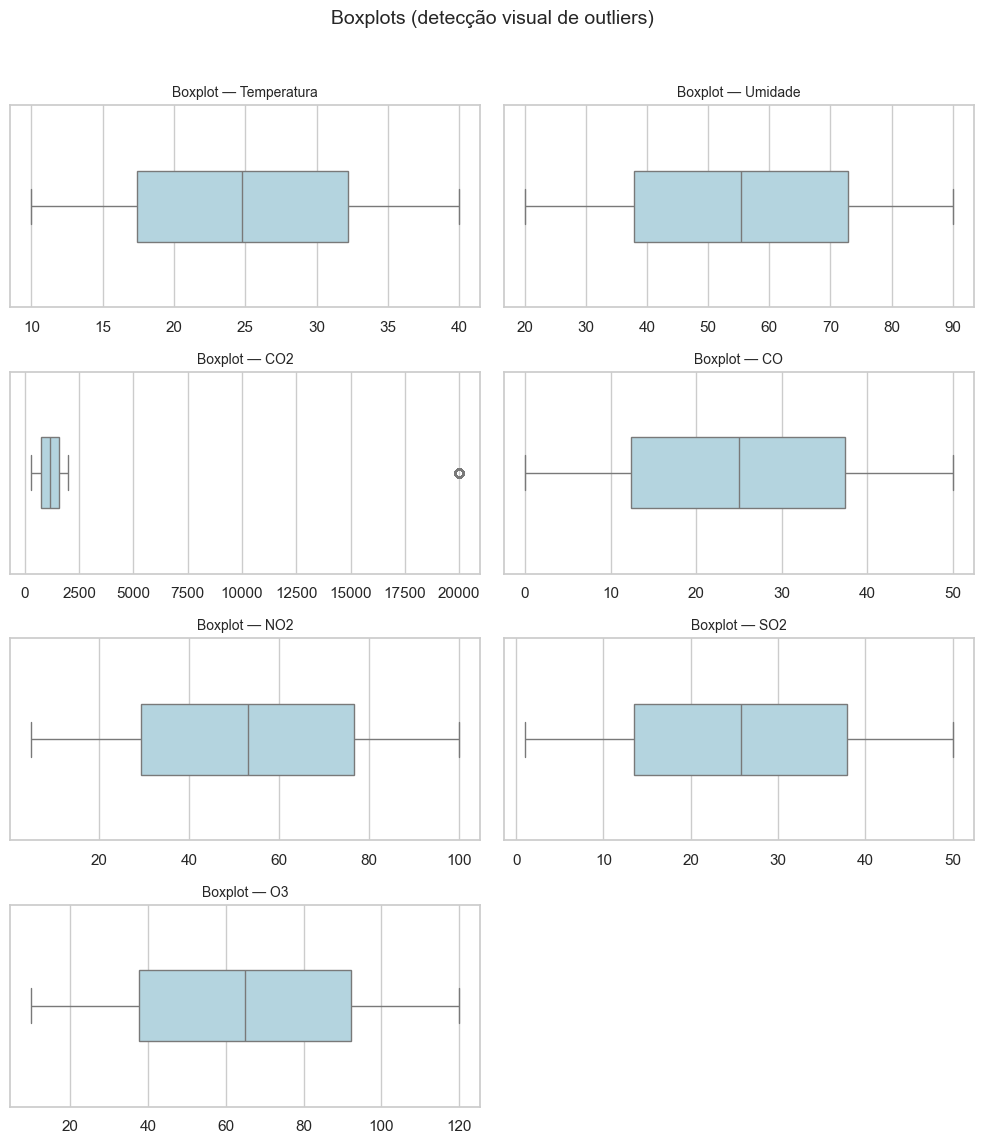

In [7]:
plot_boxplots_outliers(df, target=target)

In [8]:
# Contagem de outliers na coluna CO2 (metodo IQR)
col = "CO2"
co2 = pd.to_numeric(df[col], errors="coerce").dropna()
q1 = co2.quantile(0.25)
q3 = co2.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers = co2[(co2 < limite_inferior) | (co2 > limite_superior)]
print(f"Total de outliers em {col}: {outliers.shape[0]}")
print(f"Limite inferior: {limite_inferior:.4f}")
print(f"Limite superior: {limite_superior:.4f}")
# opcional: visualizar alguns valores outliers
outliers.head(10)

Total de outliers em CO2: 200
Limite inferior: -539.7068
Limite superior: 2872.5113


2      19998.316609
6      19998.316609
38     19998.316609
40     19998.316609
123    19998.316609
154    19998.316609
197    19998.316609
220    19998.316609
255    19998.316609
305    19998.316609
Name: CO2, dtype: float64

In [9]:
import sys
from pathlib import Path

# Reaproveita logica de descoberta da raiz para manter import estavel no notebook.
_c = Path.cwd().resolve()
_root = None
for _d in [_c, *_c.parents]:
    if (_d / "src" / "__init__.py").is_file():
        _root = _d
        break
if _root is None:
    _root = _c.parent if _c.name.lower() == "notebooks" else _c
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.train import dividir_treino_teste
from src.preprocess import encode_target_train_test

# Divide em treino e teste com estratificacao para preservar proporcao das classes.
X_train, X_test, y_train, y_test = dividir_treino_teste(X, y, test_size=0.2, random_state=42)

# Codifica y para formato numerico exigido por alguns algoritmos de ML.
y_train_enc, y_test_enc, label_encoder = encode_target_train_test(y_train, y_test)

# Verificacao simples das particoes geradas.
X_train.shape, X_test.shape

((7683, 8), (1921, 8))

**Execução:** use **Run All** a partir da primeira célula para manter a ordem das variáveis (`df`, treinos, `table`, etc.).

Se aparecer **`NameError: avaliar_modelo`**, em geral o kernel ainda tem código antigo ou o arquivo aberto não bate com o salvo no disco: **Kernel → Restart** e **Run All** de novo (e confira conflitos de salvamento no editor: não use *Revert* se a versão correta estiver só no buffer).

Há **dois blocos** em sequência (cenário CO2 com `X2_*` / comparação com `table`, e depois **FLUXO ORGANIZADO – ETAPAS 1–3** com `Xt_*` e `table_base`). O **Run All** executa os dois de propósito; não é necessário pular células no meio.

In [10]:
# CENARIO 2: tratar outliers da coluna CO2 e treinar novamente.
# Regra IQR: valores fora de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] sao considerados outliers.

co2_col = "CO2"
df_mediana_outliers = df.copy()

co2_num = pd.to_numeric(df_mediana_outliers[co2_col], errors="coerce")
q1 = co2_num.quantile(0.25)
q3 = co2_num.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

mask_outlier = (co2_num < lim_inf) | (co2_num > lim_sup)
qtd_outliers = int(mask_outlier.sum())
mediana_co2 = co2_num.median()

# Substitui apenas os outliers de CO2 pela mediana da propria coluna.
df_mediana_outliers.loc[mask_outlier, co2_col] = mediana_co2

print(f"Outliers em {co2_col} identificados: {qtd_outliers}")
print(f"Mediana usada para imputacao: {mediana_co2:.4f}")

# Recria X e y a partir do dataframe tratado.
X2, y2 = preprocessar_dados(df_mediana_outliers, target=target, drop_na=True)
X2_train, X2_test, y2_train, y2_test = dividir_treino_teste(X2, y2, test_size=0.2, random_state=42)
y2_train_enc, y2_test_enc, label_encoder2 = encode_target_train_test(y2_train, y2_test)

X2_train.shape, X2_test.shape

Outliers em CO2 identificados: 200
Mediana usada para imputacao: 1168.9364

Linhas após remoção de nulos: 9604


((7683, 8), (1921, 8))

In [11]:
# Treino dos mesmos modelos no conjunto com outliers de CO2 tratados pela mediana.
from src.train import MODEL_BUILDERS, treinar_modelo

model_names = list(MODEL_BUILDERS.keys())
models_treated = {}

for name in model_names:
    print(f"\n--- [CO2 TRATADO] Treinando: {name} ---")
    models_treated[name] = treinar_modelo(name, X2_train, y2_train_enc)


--- [CO2 TRATADO] Treinando: Random Forest ---

--- [CO2 TRATADO] Treinando: Logistic Regression ---

--- [CO2 TRATADO] Treinando: XGBoost ---


c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [12]:
# Opcional: use "Run All" a partir da primeira célula para garantir ordem e variáveis (df, X, y, etc.).

In [13]:
import importlib
import sys
from pathlib import Path

# Garante que estamos importando o modulo do projeto atual.
_c = Path.cwd().resolve()
_root = None
for _d in [_c, *_c.parents]:
    if (_d / "src" / "__init__.py").is_file():
        _root = _d
        break
if _root is None:
    _root = _c.parent if _c.name.lower() == "notebooks" else _c
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# Reload evita usar versao antiga do modulo em cache no kernel.
import src.train as train_module
importlib.reload(train_module)

treinar_modelo = train_module.treinar_modelo

# Treinamos modelos diferentes para comparar desempenho com o mesmo conjunto de dados.
model_names = ["Random Forest", "Logistic Regression", "XGBoost"]
models = {}

for name in model_names:
    print(f"\n--- Treinando: {name} ---")
    models[name] = treinar_modelo(name, X_train, y_train_enc)


--- Treinando: Random Forest ---

--- Treinando: Logistic Regression ---

--- Treinando: XGBoost ---


c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [14]:
import sys
from pathlib import Path

# Mantem import consistente para execucoes fora da ordem completa do notebook.
_c = Path.cwd().resolve()
_root = None
for _d in [_c, *_c.parents]:
    if (_d / "src" / "__init__.py").is_file():
        _root = _d
        break
if _root is None:
    _root = _c.parent if _c.name.lower() == "notebooks" else _c
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.evaluate import avaliar_modelo, build_comparison_table, print_comparison_table

rows = []

# Avalia cada modelo no conjunto de teste para estimar generalizacao.
for name, model in models.items():
    result = avaliar_modelo(model, X_test, y_test_enc, label_encoder=label_encoder)
    metrics = result["metrics"]
    report = result["report"]

    # O classification report detalha precision, recall e f1-score por classe.
    print(f"\n=== {name} | Classification report ===")
    print(report)

    rows.append({"modelo": name, **metrics})

# Consolida as metricas para facilitar a comparacao lado a lado.
table = build_comparison_table(rows)
print_comparison_table(table)
table


=== Random Forest | Classification report ===
              precision    recall  f1-score   support

         Boa       0.98      0.67      0.80       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.87      0.98      0.93      1132
  Muito Ruim       1.00      0.09      0.17        11
        Ruim       0.94      0.86      0.90       497

    accuracy                           0.90      1921
   macro avg       0.76      0.52      0.56      1921
weighted avg       0.91      0.90      0.89      1921


=== Logistic Regression | Classification report ===
              precision    recall  f1-score   support

         Boa       0.78      0.56      0.65       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.76      0.86      0.81      1132
  Muito Ruim       0.00      0.00      0.00        11
        Ruim       0.71      0.64      0.67       497

    accuracy                           0.75      1921
   macro avg       0.45      0.

c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

,modelo,accuracy,precision,recall,f1_score
0,Random Forest,0.900573,0.906516,0.900573,0.894945
1,Logistic Regression,0.752733,0.746778,0.752733,0.744977
2,XGBoost,0.930765,0.930488,0.930765,0.928942


In [15]:
# Avaliacao do cenario tratado e comparacao com o baseline.
# Executar depois da avaliacao do baseline (gera `table`) ou ter `table_base` no kernel.

import sys
from pathlib import Path

_c = Path.cwd().resolve()
_root = None
for _d in [_c, *_c.parents]:
    if (_d / "src" / "__init__.py").is_file():
        _root = _d
        break
if _root is None:
    _root = _c.parent if _c.name.lower() == "notebooks" else _c
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd

from src.evaluate import avaliar_modelo, build_comparison_table, print_comparison_table

rows_treated = []

for name, model in models_treated.items():
    result = avaliar_modelo(model, X2_test, y2_test_enc, label_encoder=label_encoder2)
    metrics = result["metrics"]
    report = result["report"]

    print(f"\n=== [CO2 TRATADO] {name} | Classification report ===")
    print(report)

    rows_treated.append({"modelo": name, **metrics})

table_treated = build_comparison_table(rows_treated)
print_comparison_table(table_treated)

# Nao use `or` com DataFrame: bool(df) levanta ValueError no pandas.
table_baseline = globals().get("table")
if table_baseline is None:
    table_baseline = globals().get("table_base")
if table_baseline is None:
    raise NameError(
        "Rode antes a célula que gera a tabela do baseline (`table` ou `table_base`)."
    )

comparacao = pd.concat(
    [
        table_baseline.assign(cenario="baseline"),
        table_treated.assign(cenario="co2_outlier_mediana"),
    ],
    ignore_index=True,
)

comparacao = comparacao[["cenario", *[c for c in comparacao.columns if c != "cenario"]]]
comparacao



=== [CO2 TRATADO] Random Forest | Classification report ===
              precision    recall  f1-score   support

         Boa       0.96      0.70      0.81       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.87      0.99      0.93      1132
  Muito Ruim       1.00      0.09      0.17        11
        Ruim       0.96      0.84      0.90       497

    accuracy                           0.90      1921
   macro avg       0.76      0.52      0.56      1921
weighted avg       0.91      0.90      0.90      1921


=== [CO2 TRATADO] Logistic Regression | Classification report ===
              precision    recall  f1-score   support

         Boa       0.96      0.92      0.94       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.97      0.98      0.97      1132
  Muito Ruim       1.00      0.45      0.62        11
        Ruim       0.96      0.97      0.96       497

    accuracy                           0.96      1921
   

c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

,cenario,modelo,accuracy,precision,recall,f1_score
0,baseline,Random Forest,0.900573,0.906516,0.900573,0.894945
1,baseline,Logistic Regression,0.752733,0.746778,0.752733,0.744977
2,baseline,XGBoost,0.930765,0.930488,0.930765,0.928942
3,co2_outlier_mediana,Random Forest,0.901614,0.907374,0.901614,0.896364
4,co2_outlier_mediana,Logistic Regression,0.964602,0.963661,0.964602,0.963460
5,co2_outlier_mediana,XGBoost,0.929724,0.929369,0.929724,0.928385


In [16]:
# FLUXO ORGANIZADO - ETAPA 1 (BASELINE)
# Treina os modelos com os dados originais (sem tratamento de outliers).

import importlib
import sys
from pathlib import Path

import src.train as train_module

importlib.reload(train_module)

from src.preprocess import preprocessar_dados, encode_target_train_test
from src.train import dividir_treino_teste
from src.evaluate import avaliar_modelo, build_comparison_table, print_comparison_table

# Raiz do projeto no path (para importar mlflow_utils ao lado de src/)
for _nb_root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (_nb_root / "mlflow_utils.py").is_file() and (_nb_root / "src" / "__init__.py").is_file():
        if str(_nb_root) not in sys.path:
            sys.path.insert(0, str(_nb_root))
        break
else:
    _nb_root = Path.cwd().resolve()

# MLflow só no notebook: grava em <projeto>/mlruns (sem variável de ambiente).
# Na raiz do projeto, para ver na UI: mlflow ui --backend-store-uri file:./mlruns --port 5000
# Opcional: apontar para servidor já aberto → _NOTEBOOK_MLFLOW_URI = "http://127.0.0.1:5000"
LOG_TO_MLFLOW = True
(_nb_root / "mlruns").mkdir(parents=True, exist_ok=True)
_NOTEBOOK_MLFLOW_URI = (_nb_root / "mlruns").resolve().as_uri()

if LOG_TO_MLFLOW:
    from mlflow_utils import configure_tracking

    configure_tracking(_NOTEBOOK_MLFLOW_URI)
    print("MLflow tracking URI:", _NOTEBOOK_MLFLOW_URI)

model_names = ["Random Forest", "Logistic Regression", "XGBoost"]

X_base, y_base = preprocessar_dados(df, target=target, drop_na=True)
Xb_train, Xb_test, yb_train, yb_test = dividir_treino_teste(X_base, y_base, test_size=0.2, random_state=42)
yb_train_enc, yb_test_enc, le_base = encode_target_train_test(yb_train, yb_test)

models_base = {}
for name in model_names:
    print(f"\n--- [BASELINE] Treinando: {name} ---")
    models_base[name] = train_module.treinar_modelo(name, Xb_train, yb_train_enc)

rows_base = []
for name, model in models_base.items():
    result = avaliar_modelo(model, Xb_test, yb_test_enc, label_encoder=le_base)
    print(f"\n=== [BASELINE] {name} | Classification report ===")
    print(result["report"])
    rows_base.append({"modelo": name, **result["metrics"]})
    if LOG_TO_MLFLOW:
        from mlflow_utils import log_classification_training_run

        rid, _ = log_classification_training_run(
            model=model,
            X_train=Xb_train,
            X_test=Xb_test,
            y_test_enc=yb_test_enc,
            model_display_name=name,
            scenario="notebook_baseline",
            study="qualidade_ambiental",
            metrics=result["metrics"],
            csv_path=str(csv_path.resolve()),
            target_column=target,
            tags_extra={"source": "jupyter"},
        )
        print(f"MLflow run_id [baseline] {name}: {rid}")

table_base = build_comparison_table(rows_base)
print_comparison_table(table_base)
table_base

c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking URI: file:///C:/Projetos%20Programa%C3%A7%C3%A3o/Cursor/Desafio%203%20-%20Machine%20Learning/mlruns

Linhas após remoção de nulos: 9604

--- [BASELINE] Treinando: Random Forest ---

--- [BASELINE] Treinando: Logistic Regression ---

--- [BASELINE] Treinando: XGBoost ---


c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali


=== [BASELINE] Random Forest | Classification report ===
              precision    recall  f1-score   support

         Boa       0.98      0.67      0.80       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.87      0.98      0.93      1132
  Muito Ruim       1.00      0.09      0.17        11
        Ruim       0.94      0.86      0.90       497

    accuracy                           0.90      1921
   macro avg       0.76      0.52      0.56      1921
weighted avg       0.91      0.90      0.89      1921



2026/03/26 10:43:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 10:43:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: Unde

...

c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

MLflow run_id [baseline] Logistic Regression: 2336db2bca6d41878d378889eabdad95

=== [BASELINE] XGBoost | Classification report ===
              precision    recall  f1-score   support

         Boa       0.96      0.81      0.88       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.92      0.97      0.95      1132
  Muito Ruim       0.83      0.45      0.59        11
        Ruim       0.94      0.92      0.93       497

    accuracy                           0.93      1921
   macro avg       0.73      0.63      0.67      1921
weighted avg       0.93      0.93      0.93      1921



2026/03/26 10:44:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run_id [baseline] XGBoost: 1d542e803c2a40ad99594da77a6df880

=== COMPARAÇÃO DE MODELOS (média ponderada por classe) ===
             modelo accuracy precision recall f1_score
      Random Forest   0.9006    0.9065 0.9006   0.8949
Logistic Regression   0.7527    0.7468 0.7527   0.7450
            XGBoost   0.9308    0.9305 0.9308   0.9289


,modelo,accuracy,precision,recall,f1_score
0,Random Forest,0.900573,0.906516,0.900573,0.894945
1,Logistic Regression,0.752733,0.746778,0.752733,0.744977
2,XGBoost,0.930765,0.930488,0.930765,0.928942


In [17]:
# FLUXO ORGANIZADO - ETAPA 2 (TRATAR OUTLIERS DE CO2 COM MEDIANA)
# Identifica outliers por IQR e substitui apenas esses valores pela mediana de CO2.

co2_col = "CO2"
df_tratado = df.copy()

co2_num = pd.to_numeric(df_tratado[co2_col], errors="coerce")
q1 = co2_num.quantile(0.25)
q3 = co2_num.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

mask_outlier = (co2_num < lim_inf) | (co2_num > lim_sup)
qtd_outliers = int(mask_outlier.sum())
mediana_co2 = co2_num.median()

df_tratado.loc[mask_outlier, co2_col] = mediana_co2

print(f"Outliers identificados em {co2_col}: {qtd_outliers}")
print(f"Faixa aceitavel (IQR): [{lim_inf:.4f}, {lim_sup:.4f}]")
print(f"Mediana usada na substituicao: {mediana_co2:.4f}")

X_treated, y_treated = preprocessar_dados(df_tratado, target=target, drop_na=True)
Xt_train, Xt_test, yt_train, yt_test = dividir_treino_teste(X_treated, y_treated, test_size=0.2, random_state=42)
yt_train_enc, yt_test_enc, le_treated = encode_target_train_test(yt_train, yt_test)

model_names = list(train_module.MODEL_BUILDERS.keys())
models_treated = {}
for name in model_names:
    print(f"\n--- [CO2 TRATADO] Treinando: {name} ---")
    models_treated[name] = train_module.treinar_modelo(name, Xt_train, yt_train_enc)

Outliers identificados em CO2: 200
Faixa aceitavel (IQR): [-539.7068, 2872.5113]
Mediana usada na substituicao: 1168.9364

Linhas após remoção de nulos: 9604

--- [CO2 TRATADO] Treinando: Random Forest ---

--- [CO2 TRATADO] Treinando: Logistic Regression ---

--- [CO2 TRATADO] Treinando: XGBoost ---


c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [18]:
# FLUXO ORGANIZADO - ETAPA 3 (AVALIACAO FINAL E COMPARACAO)
# Compara as metricas antes e depois do tratamento dos outliers de CO2.

rows_treated = []
for name, model in models_treated.items():
    result = avaliar_modelo(model, Xt_test, yt_test_enc, label_encoder=le_treated)
    print(f"\n=== [CO2 TRATADO] {name} | Classification report ===")
    print(result["report"])
    rows_treated.append({"modelo": name, **result["metrics"]})
    if globals().get("LOG_TO_MLFLOW", False):
        from mlflow_utils import log_classification_training_run

        rid, _ = log_classification_training_run(
            model=model,
            X_train=Xt_train,
            X_test=Xt_test,
            y_test_enc=yt_test_enc,
            model_display_name=name,
            scenario="notebook_co2_mediana",
            study="qualidade_ambiental",
            metrics=result["metrics"],
            csv_path=str(csv_path.resolve()),
            target_column=target,
            tags_extra={"source": "jupyter"},
        )
        print(f"MLflow run_id [CO2 mediana] {name}: {rid}")

table_treated = build_comparison_table(rows_treated)
print_comparison_table(table_treated)

comparacao_final = pd.concat(
    [
        table_base.assign(cenario="baseline"),
        table_treated.assign(cenario="co2_outlier_mediana"),
    ],
    ignore_index=True,
)

comparacao_final = comparacao_final[["cenario", *[c for c in comparacao_final.columns if c != "cenario"]]]
comparacao_final

c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 


=== [CO2 TRATADO] Random Forest | Classification report ===
              precision    recall  f1-score   support

         Boa       0.96      0.70      0.81       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.87      0.99      0.93      1132
  Muito Ruim       1.00      0.09      0.17        11
        Ruim       0.96      0.84      0.90       497

    accuracy                           0.90      1921
   macro avg       0.76      0.52      0.56      1921
weighted avg       0.91      0.90      0.90      1921



c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

MLflow run_id [CO2 mediana] Random Forest: 81d4ba24a2354f6ab073dfe3e005b2df

=== [CO2 TRATADO] Logistic Regression | Classification report ===
              precision    recall  f1-score   support

         Boa       0.96      0.92      0.94       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.97      0.98      0.97      1132
  Muito Ruim       1.00      0.45      0.62        11
        Ruim       0.96      0.97      0.96       497

    accuracy                           0.96      1921
   macro avg       0.78      0.66      0.70      1921
weighted avg       0.96      0.96      0.96      1921



c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

MLflow run_id [CO2 mediana] Logistic Regression: c9ce0ba4985e4c9c9172ba1bb34e2c2e

=== [CO2 TRATADO] XGBoost | Classification report ===
              precision    recall  f1-score   support

         Boa       0.94      0.82      0.88       279
   Excelente       0.00      0.00      0.00         2
    Moderada       0.92      0.97      0.94      1132
  Muito Ruim       1.00      0.64      0.78        11
        Ruim       0.94      0.92      0.93       497

    accuracy                           0.93      1921
   macro avg       0.76      0.67      0.71      1921
weighted avg       0.93      0.93      0.93      1921



2026/03/26 10:44:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run_id [CO2 mediana] XGBoost: 8daa0e0020ff446b92949464d2ec5b55

=== COMPARAÇÃO DE MODELOS (média ponderada por classe) ===
             modelo accuracy precision recall f1_score
      Random Forest   0.9016    0.9074 0.9016   0.8964
Logistic Regression   0.9646    0.9637 0.9646   0.9635
            XGBoost   0.9297    0.9294 0.9297   0.9284


,cenario,modelo,accuracy,precision,recall,f1_score
0,baseline,Random Forest,0.900573,0.906516,0.900573,0.894945
1,baseline,Logistic Regression,0.752733,0.746778,0.752733,0.744977
2,baseline,XGBoost,0.930765,0.930488,0.930765,0.928942
3,co2_outlier_mediana,Random Forest,0.901614,0.907374,0.901614,0.896364
4,co2_outlier_mediana,Logistic Regression,0.964602,0.963661,0.964602,0.963460
5,co2_outlier_mediana,XGBoost,0.929724,0.929369,0.929724,0.928385


## 9. Ajuste fino da **Logistic Regression** (dados com mediana nos outliers de CO2)

Busca em grade (`GridSearchCV`) sobre **C** e **class_weight** com a mesma pipeline de pré-processamento, validação **estratificada** e métrica **F1 ponderado** na CV. No final comparamos com a Logistic Regression **default** já treinada em `models_treated`.

**Requisito:** ter executado as células do fluxo CO2 tratado (`Xt_train`, `yt_train_enc`, `Xt_test`, `yt_test_enc`, `le_treated`, `models_treated`).


In [19]:
import importlib
import sys
from pathlib import Path

import pandas as pd

import src.train as train_module

importlib.reload(train_module)

from src.evaluate import avaliar_modelo, print_comparison_table, build_comparison_table

# Se rodar sem a ETAPA 1: mesma pasta mlruns do projeto (igual à célula baseline)
if "LOG_TO_MLFLOW" not in globals():
    LOG_TO_MLFLOW = True
    for _nr in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (_nr / "mlflow_utils.py").is_file() and (_nr / "src" / "__init__.py").is_file():
            if str(_nr) not in sys.path:
                sys.path.insert(0, str(_nr))
            break
    else:
        _nr = Path.cwd().resolve()
    (_nr / "mlruns").mkdir(parents=True, exist_ok=True)
    _uri_lr = (_nr / "mlruns").resolve().as_uri()
    from mlflow_utils import configure_tracking

    configure_tracking(_uri_lr)
    print("MLflow tracking URI:", _uri_lr)

# Ajuste fino: 13 valores de C (logspace) x 2 class_weight = 26 combinações x 5 folds
gs_lr = train_module.treinar_logistic_regression_tunado(
    Xt_train,
    yt_train_enc,
    cv=5,
    random_state=42,
    scoring="f1_weighted",
    verbose=1,
)

print("\nMelhores hiperparâmetros (CV):", gs_lr.best_params_)
print(f"Melhor F1 weighted (média CV): {gs_lr.best_score_:.6f}")

result_tunado = avaliar_modelo(
    gs_lr, Xt_test, yt_test_enc, label_encoder=le_treated
)
print("\n=== Logistic Regression tunada | conjunto de teste ===")
print(result_tunado["report"])

if globals().get("LOG_TO_MLFLOW", False):
    from mlflow_utils import log_classification_training_run

    rid_lr, _ = log_classification_training_run(
        model=gs_lr,
        X_train=Xt_train,
        X_test=Xt_test,
        y_test_enc=yt_test_enc,
        model_display_name="Logistic Regression",
        scenario="notebook_lr_gridsearch",
        study="qualidade_ambiental",
        metrics=result_tunado["metrics"],
        csv_path=str(csv_path.resolve()),
        target_column=target,
        tags_extra={"source": "jupyter"},
    )
    print(f"MLflow run_id [LR tunada GridSearchCV]: {rid_lr}")

result_default = avaliar_modelo(
    models_treated["Logistic Regression"],
    Xt_test,
    yt_test_enc,
    label_encoder=le_treated,
)

rows_cmp = [
    {"modelo": "LR default (CO2 mediana)", **result_default["metrics"]},
    {"modelo": "LR tunada (GridSearchCV)", **result_tunado["metrics"]},
]
table_lr = build_comparison_table(rows_cmp)
print_comparison_table(table_lr)
table_lr


Fitting 5 folds for each of 26 candidates, totalling 130 fits


2026/03/26 10:44:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Melhores hiperparâmetros (CV): {'model__classifier__C': 100.0, 'model__classifier__class_weight': None}
Melhor F1 weighted (média CV): 0.968610

=== Logistic Regression tunada | conjunto de teste ===
              precision    recall  f1-score   support

         Boa       0.96      0.92      0.94       279
   Excelente       0.67      1.00      0.80         2
    Moderada       0.97      0.98      0.97      1132
  Muito Ruim       0.91      0.91      0.91        11
        Ruim       0.97      0.97      0.97       497

    accuracy                           0.97      1921
   macro avg       0.89      0.96      0.92      1921
weighted avg       0.97      0.97      0.97      1921



2026/03/26 10:44:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run_id [LR tunada GridSearchCV]: 07f51758d66a4a4e8ece43a284c73a5f

=== COMPARAÇÃO DE MODELOS (média ponderada por classe) ===
                  modelo accuracy precision recall f1_score
LR default (CO2 mediana)   0.9646    0.9637 0.9646   0.9635
LR tunada (GridSearchCV)   0.9672    0.9673 0.9672   0.9672


c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projetos Programação\Cursor\Desafio 3 - Machine Learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

,modelo,accuracy,precision,recall,f1_score
0,LR default (CO2 mediana),0.964602,0.963661,0.964602,0.963460
1,LR tunada (GridSearchCV),0.967205,0.967306,0.967205,0.967168
